In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import ADASYN
from collections import Counter


In [3]:
data=pd.read_csv('../../data/processed/selected_data.csv')
data.head()

,Date,Shanghai Comp,KODEX 200,TOPIX,Brent Crude Oil,Gold Spot,JPY/KRW,USD/KRW,NASDAQ,KOSDAQ,...,GJR_VaR_95,Signal1_Buy,Signal1_Sell,Signal2_Buy,Signal2_Sell,Signal3_Buy,Signal3_Sell,Signal4_Buy,Signal4_Sell,Risk_Label
0,2009-04-17,2503.935059,17370.0,875.0,51.959999,867.400024,13.371,1325.800049,1673.069946,483.799988,...,-2.246073,0,0,0,0,0,0,0,0,lowrisk
1,2009-04-20,2557.456055,17480.0,876.0,51.959999,887.000000,13.536,1327.500000,1608.209961,491.940002,...,-2.169582,0,0,0,0,0,0,0,0,lowrisk
2,2009-04-21,2535.827881,17480.0,855.0,51.959999,882.099976,13.727,1354.300049,1643.849976,497.190002,...,-2.062932,0,0,0,0,0,0,0,0,lowrisk
3,2009-04-22,2461.345947,17715.0,856.0,51.959999,891.799988,13.726,1346.599976,1646.119995,509.899994,...,-2.000966,0,0,0,0,0,0,0,0,lowrisk
4,2009-04-23,2463.954102,17895.0,862.0,51.959999,905.900024,13.618,1333.599976,1652.209961,514.090027,...,-1.900311,0,0,0,0,0,1,0,0,lowrisk


In [18]:
# train:valid:test 5:3:2
train_data=data.iloc[:int(0.5*len(data))]
valid_data=data.iloc[int(0.5*len(data)):int(0.8*len(data))]
test_data=data.iloc[int(0.8*len(data)):]


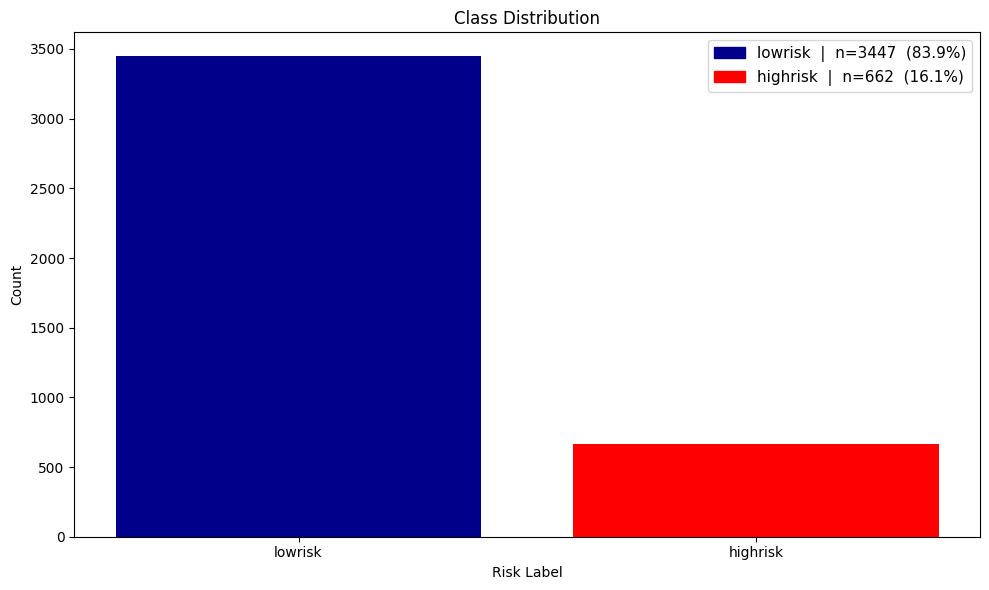

In [35]:
# 클래스 불균형 확인
counts = data['Risk_Label'].value_counts()
colors = {'lowrisk': 'darkblue', 'highrisk': 'red'}
total = counts.sum()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    counts.index,
    counts.values,
    color=[colors.get(k, 'grey') for k in counts.index]
)

legend_labels = [
    f"{idx}  |  n={cnt}  ({cnt/total*100:.1f}%)"
    for idx, cnt in zip(counts.index, counts.values)
]
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=colors.get(idx, 'grey'))
    for idx in counts.index
]
ax.legend(legend_patches, legend_labels, fontsize=11)

ax.set_xlabel('Risk Label')
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()


### **ADA**ptive **SYN**

In [20]:
# 1. X, y 분리 (Date는 인덱스로 설정, 피처에서 제외)
X = train_data.drop(columns=['Date', 'Risk_Label'])
y = train_data['Risk_Label']

print("원본 클래스 분포:", Counter(y))

# 2. ADASYN 적용
adasyn = ADASYN(
    sampling_strategy='auto',
    random_state=1,
    n_neighbors=5
)

X_resampled, y_resampled = adasyn.fit_resample(X, y)


원본 클래스 분포: Counter({'lowrisk': 1764, 'highrisk': 290})


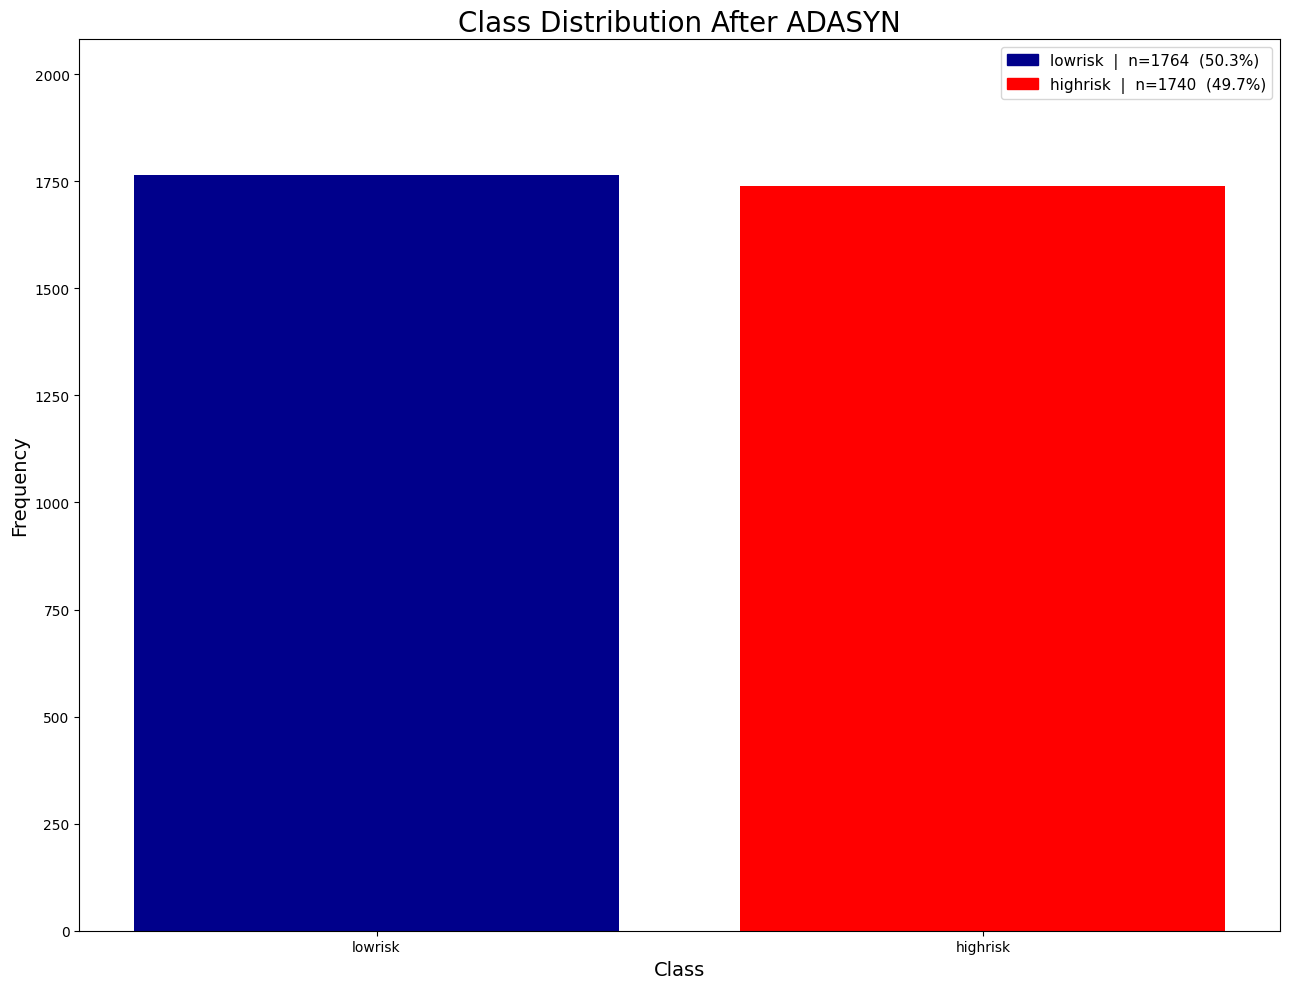

In [34]:
counts = pd.Series(y_resampled).value_counts()
colors = {'lowrisk': 'darkblue', 'highrisk': 'red'}
total = counts.sum()

fig, ax = plt.subplots(figsize=(13, 10))
bars = ax.bar(
    counts.index,
    counts.values,
    color=[colors.get(k, 'grey') for k in counts.index]
)

# legend에 index, count, 비율 표시
legend_labels = [
    f"{idx}  |  n={cnt}  ({cnt/total*100:.1f}%)"
    for idx, cnt in zip(counts.index, counts.values)
]
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=colors.get(idx, 'grey'))
    for idx in counts.index
]
ax.legend(legend_patches, legend_labels, fontsize=11)

ax.set_xlabel('Class',fontsize=14)
ax.set_ylabel('Frequency',fontsize=14)
ax.set_title('Class Distribution After ADASYN',fontsize=20)
plt.ylim(0, max(counts.values) * 1.18)  # y축 범위 조정
plt.tight_layout()
plt.show()


In [22]:

# 3. 다시 데이터프레임으로 합치기
train_data_adasyn = X_resampled.copy()
train_data_adasyn['Risk_Label'] = y_resampled
train_data_adasyn.head()


,Shanghai Comp,KODEX 200,TOPIX,Brent Crude Oil,Gold Spot,JPY/KRW,USD/KRW,NASDAQ,KOSDAQ,KOSPI 200 Close,...,GJR_VaR_95,Signal1_Buy,Signal1_Sell,Signal2_Buy,Signal2_Sell,Signal3_Buy,Signal3_Sell,Signal4_Buy,Signal4_Sell,Risk_Label
0,2503.935059,17370.0,875.0,51.959999,867.400024,13.371,1325.800049,1673.069946,483.799988,171.330002,...,-2.246073,0,0,0,0,0,0,0,0,lowrisk
1,2557.456055,17480.0,876.0,51.959999,887.000000,13.536,1327.500000,1608.209961,491.940002,172.300003,...,-2.169582,0,0,0,0,0,0,0,0,lowrisk
2,2535.827881,17480.0,855.0,51.959999,882.099976,13.727,1354.300049,1643.849976,497.190002,171.960007,...,-2.062932,0,0,0,0,0,0,0,0,lowrisk
3,2461.345947,17715.0,856.0,51.959999,891.799988,13.726,1346.599976,1646.119995,509.899994,174.399994,...,-2.000966,0,0,0,0,0,0,0,0,lowrisk
4,2463.954102,17895.0,862.0,51.959999,905.900024,13.618,1333.599976,1652.209961,514.090027,176.139999,...,-1.900311,0,0,0,0,0,1,0,0,lowrisk


In [23]:
# 약 1500개 증가
print(len(train_data))
print(len(train_data_adasyn))

2054
3504
